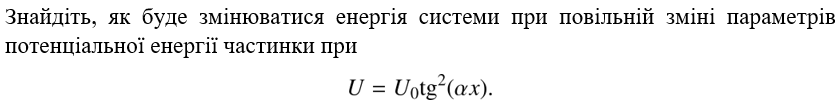

In [ ]:
from IPython.display import display, Math, Latex

def disp(ex):
    display(Math(latex(ex)))

In [ ]:
# Объявление переменных и функций

U_0 = var("U_0")
m,t = var("m,t")

V = var("v")
v = function("v")(t)

X = var("x")
x = function("x")(t)

P = var("p")
p = function("p")(t)

Alpha = var("alpha")
alpha = function("alpha")(t)

a = var("a")

In [ ]:
U = - U_0 / cosh(X/a)^2

In [ ]:
pl  = plot(U.subs([U_0 == 1, a == 1]), X)
pl += plot(U.subs([U_0 == 1.1, a == 1]), X, color="red")
pl += plot(U.subs([U_0 == 1.2, a == 1]), X, color="green")
pl.show()

In [ ]:
pl  = plot(U.subs([U_0 == 1, a == 1]), X)
pl += plot(U.subs([U_0 == 1, a == 0.25]), X, color="red")
pl += plot(U.subs([U_0 == 1, a == 0.5]), X, color="green")
pl.show()

In [ ]:
# Кинетическая энергия в координатах x

Tx = (1/2) * m*((x.diff(t))^2)
disp(Tx)

In [ ]:
# Кинетическая энергия в координатах p

Tp = (1/2) * ((P)^2) / m
disp(Tp)

In [ ]:
# уравнения замены производных обобщенных координат на v

subs_to_v      = [x.diff(t) == V]
subs_to_v_func = [x.diff(t) == v]

In [ ]:
# уравнения замены производных обобщенных координат на p

subs_to_p      = [x.diff(t) == P/m]
subs_to_p_func = [x.diff(t) == p/m]

In [ ]:
# Потенциальная энергия в координатах x

# U = U_0 * tan(alpha * x)^2
#U = U_0 * alpha * x^2
U = - U_0 / cosh(x/a)^2
disp(U)

In [ ]:
# производная потенциальной энергии по координате
dUdX = diff(U.subs(x == X), X)
disp(dUdX)

In [ ]:
# находим точку минимума потенциальной энергии
# приравнивая первую производную потенциальной энергии нулю

eq = dUdX.subs(alpha == Alpha) == 0
disp(eq)
disp(eq.lhs().operands())
# disp(solve (eq, X))
U_min = []
for operand in eq.lhs().operands():
    U_min += solve (operand == 0, X)
disp(U_min)

In [ ]:
# координата минимума потенциальной энергии
X_U_min = X.subs(U_min)
X_U_min

In [ ]:
# производная потенциальной энергии по координате
# в точке минимума потенциальной энергии
disp(dUdX.subs(U_min))

In [ ]:
# вторая производная потенциальной энергии по координате
# в точке минимума потенциальной энергии
d2UdX2 = diff(U.subs(x == X), X, 2)
disp(d2UdX2)
disp(d2UdX2.subs(U_min))

In [ ]:
# Процедура линеаризации
# разложение потенциальной энергии в Ряд Тейлора до второго порядка
# относительно координаты минимума потенциальной энергии
U_tailor_2 = dUdX.subs(U_min) * (X - X_U_min)^1 / 1 \
           + d2UdX2.subs(U_min) * (X - X_U_min)^2 / 2
disp(U_tailor_2)

In [ ]:
# Лагранжиан в Ряд Тейлора
L_tailor_2 = Tx - U_tailor_2
disp(L_tailor_2)

# в Лагранжиане производим замену производных обобщенных координат на v
L_tailor_2 = L_tailor_2.subs(x.diff(t) == V).subs(alpha == Alpha)
disp(L_tailor_2)

# Найдем обобщенные импульсы
P1_tailor_2 = L_tailor_2.diff(V).subs(V == v)
disp(P1_tailor_2)

# Найдем обобщенные силы
F1_tailor_2 = L_tailor_2.subs(x == X).diff(X).subs(X == x)
disp(F1_tailor_2)

# Запишем уравнения Эйлера-Лагранжа
de1_tailor_2 = P1_tailor_2.diff(t) - F1_tailor_2 == 0
disp(de1_tailor_2)

de1_tailor_2 = de1_tailor_2.substitute_function(v == x.diff(t))
disp(de1_tailor_2)

assume(U_0>0)
assume(Alpha>0)
assume(m>0)
sol_tailor_2 = desolve(de1_tailor_2, x, ivar=t, algorithm='maxima')
disp(sol_tailor_2)

sol_tailor_2_fricas = desolve(de1_tailor_2, x, ivar=t, algorithm='fricas')
disp(sol_tailor_2_fricas)

In [ ]:
# Лагранжиан

L = Tx - U
disp(L)

In [ ]:
# Гамильтониан

H = Tp + U
disp(H)

In [ ]:
# в Лагранжиане производим замену производных обобщенных координат на v

L = L.subs(subs_to_v)
disp(L)

Найдем обобщенные импульсы

$P = \frac{\partial L}{\partial \dot{x}} = \frac{\partial L}{\partial {v}}$

In [ ]:
P1 = L.diff(V).subs(V == v)
disp(P1)

Найдем обобщенные силы

$\frac{\partial L}{\partial {x}} = F$

In [ ]:
F1 = L.subs(x == X).diff(X).subs(X == x)
disp(F1)

Запишем уравнения Эйлера-Лагранжа

$\frac{d}{dt}\frac{\partial L}{\partial \dot{x}} - \frac{\partial L}{\partial {x}} = 0$

In [ ]:
de1 = P1.diff(t) - F1 == 0
disp(de1)

In [ ]:
disp(de1.full_simplify().expand())

Выразим энергию через Лагранжиан

$E = \Sigma_{i}^{} \frac {\partial L}{\partial \dot{q}_i} \frac {q_i}{dt} - L$

In [ ]:
Energy = P1 * v - L
Energy = Energy.subs(v == V, x == X)
disp (Energy)

In [ ]:
Energy1 = Energy.subs(m == 1, a == 1, U_0 == 1)
disp (Energy1)

In [ ]:
contour_plot(Energy1, (X,-pi,pi), (V,-pi,pi),
              fill=False, cmap='hsv', labels=True)

In [ ]:
@interact
def _(a=slider(srange(.1,10,.1),default = 2),
      m=slider(srange(.1,10,.1),default = 2),
      u0=slider(srange(.1,10,.1),default = 2)):
    contour_plot(Energy.subs(var("m") == m, var("a") == a, U_0 == u0),
                 (X,-pi,pi), (V,-pi,pi),
              fill=False, cmap='hsv', labels=True, contours=25).show(
        title="a=%0.2f, m=%0.2f, U_0=%0.2f"%(a, m, u0))

# Поиск периода колебаний

In [ ]:
# Запишем дифференциальное уравнение выражающее закон сохранения энергии
E = var("E")
de_E = E == (P1 * v - L).subs(V == v, alpha == Alpha).substitute_function(v == x.diff(t))
disp(de_E)

In [ ]:
# выражаем производную координаты по времени через энергию
# подготавливаем полученное дифференциальное уравнение к дифференцированию

sol_dxdt_E = solve(de_E, x.diff(t))
disp(sol_dxdt_E)

Разделяя переменные интегрируем полученное выражение по координате 
от минимальной координаты до максимальной
получаем выражение для периода колебаний

Максимальная и минимальная координата находятся из условия равенства полной энергии потенциальной энергии или равенства кинетической энергии нулю

In [ ]:
# уравнение в котором приравниваем полную энергию E потенциальной энергии

eq_E_U = E == (P1 * V - L).subs(v == V, alpha == Alpha).subs(V == 0).subs(x == X)
disp(eq_E_U)

In [ ]:
# решая его получаем точки, в котором потенциальная энергия равна полной

sol_x_E = solve(eq_E_U, X)
disp(sol_x_E)

In [ ]:
# разделяем переменные в дифференциальном уравнении
# выражающем закон сохранения энергии
# получаем интегранд при dx
dx_integrand = 1/sol_dxdt_E[0].rhs().subs(x == X)
disp(dx_integrand)

In [ ]:
z = var("z")
#z = x/a
#dx = a * dz

In [ ]:
diff(cosh(z), z)

In [ ]:
diff(sinh(z), z)

In [ ]:
dz_integrand = a*dx_integrand.subs(X == a*z)
disp(dz_integrand)

In [ ]:
y = var("y")
# cosh(z) * dz = d (sinh(z))
# y = sinh(z)

In [ ]:
(cosh(z)^2 - sinh(z)^2).full_simplify()

In [ ]:
# cosh(z)^2 = 1 + sinh(z)^2
# cosh(z)^2 = 1 + y^2

In [ ]:
dy_integrand = (dz_integrand / cosh(z)).subs(cosh(z)^2 == 1 + y^2)
disp(dy_integrand)

In [ ]:
# интегрируем интегранд при dx по иксу
forget()
assume(E<0)
assume(U_0+E<0)
assume(m>0)
t_integral_y_ = dy_integrand.integrate(y, algorithm = "maxima")

disp(t_integral_y_)

In [ ]:
# интегрируем интегранд при dx по иксу
forget()
assume(E<0)
assume(U_0+E>0)
assume(m>0)
t_integral_y = dy_integrand.integrate(y, algorithm = "maxima")

disp(t_integral_y)

In [ ]:
disp(sol_x_E[1])

пределы интегрування по y

In [ ]:
y1 = sinh(X/a).subs(sol_x_E[0])
disp(y1)

In [ ]:
y1 = sqrt((y1^2).full_simplify())
disp(y1)

In [ ]:
y2 = sinh(X/a).subs(sol_x_E[1])
disp(y2)

In [ ]:
y2 = sqrt((y2^2).full_simplify())
disp(y2)

подставляем в неопределённый интеграл точки, в котором потенциальная энергия равна полной

In [ ]:
t_integral_y2 = t_integral_y.subs(y == y2)
disp(t_integral_y2)

In [ ]:
t_integral_y2_operands = t_integral_y2.operands()
disp(t_integral_y2_operands)

In [ ]:
arcsin_argument = t_integral_y2_operands[3].operands()[0]
disp(arcsin_argument)

In [ ]:
arcsin_argument_simplified = sqrt((arcsin_argument^2).full_simplify())
disp(arcsin_argument_simplified)

In [ ]:
t_integral_y2.operator()

In [ ]:
def my_simplify(t_integral):
    t_integral_simplified = 1
    for t_integral_operand in t_integral.operands():
        if t_integral_operand.operator() == arcsin:
            arcsin_argument = t_integral_operand.operands()[0]
            arcsin_argument_simplified = sqrt((arcsin_argument^2).full_simplify())
            t_integral_simplified *= arcsin(arcsin_argument_simplified)
        else:
            t_integral_simplified *= t_integral_operand
    return t_integral_simplified

In [ ]:
t_integral_y2_simplified = my_simplify(t_integral_y2)

In [ ]:
disp(t_integral_y2_simplified)

Период

In [ ]:
T = 2*2 * t_integral_y2_simplified
disp(T)

подставляем в неопределённый интеграл точки, в котором потенциальная энергия равна полной

In [ ]:
t_integral_x = t_integral_y.subs(y == sinh(X/a))
disp(t_integral_x)

In [ ]:
t_integral_x1 = t_integral_x.subs(sol_x_E[0])
disp(t_integral_x1)

In [ ]:
t_integral_x2 = t_integral_x.subs(sol_x_E[1])
disp(t_integral_x2)

In [ ]:
t_integral_x2_simplified = my_simplify(t_integral_x2)
disp(t_integral_x2_simplified)

In [ ]:
t_integral_x1_simplified = my_simplify(t_integral_x1)
disp(t_integral_x1_simplified)

Период

In [ ]:
T = t_integral_x2 - t_integral_x1
disp(T)

In [ ]:
disp(T.full_simplify())

# Интегрирование уравнений Гамильтона

In [ ]:
# Объявление переменных - обобщенные импульсы

p_1, p_2 = var ("p_1, p_2")

In [ ]:
# Записываем уравнения выражающие обобщенные импульсы
# через производные Лагранжиана по скорости изменения обобщенной координаты (по v)

eq_p_v = [p_1 == L.diff(V)]
disp(eq_p_v[0])

In [ ]:
# Ищем выражение для v через обобщенные импульсы, решая вышесозданную систему уравнений

sol_v_p = solve(eq_p_v, [V])
disp(sol_v_p)

In [ ]:
# Находим выражение для Гамильтониана исходя из
# выражения энергии через Лагранжиан
# используя вышенайденную подстановку, выражающую omega через обобщенные импульсы и координаты

H = (p_1 * V - L).subs(sol_v_p).subs(x == X)
disp(H)

Записываем уравнения Гамильтона

$\dot{p}_i = - \frac{\partial H}{\partial q_i}$

$\dot{q}_i = \frac{\partial H}{\partial p_i}$

In [ ]:
dot_p1 = - H.diff(X)
dot_x1 =   H.diff(p_1)

In [ ]:
disp(dot_p1)

In [ ]:
disp(dot_x1)

In [ ]:
# полученные уравнения Гамильтона обьединяем в систему из 2 уравнений
des = [dot_p1, dot_x1]
disp(des)

In [ ]:
a_subs = a == 2# + 0.1 * t
a_subs

In [ ]:
values = [U_0 == 1, m == 1, a_subs]
values

In [ ]:
H_subs = H.subs(values)
H_subs

In [ ]:
# в которой делаем подстановку численных значений масс, длин и ускорения свободного падения
f = [de_i.subs(values) for de_i in des]
disp(f)

In [ ]:
# Solve numerically a system of first-order ordinary differential equations
# using odeint from scipy.integrate module.

# des – right hand sides of the system
# ics – initial conditions
# times – a sequence of time points in which the solution must be found
# dvars – dependent variables. ATTENTION: the order must be the same as in des, that means: d(dvars[i])/dt=des[i]
# ivar – independent variable, optional.

times = srange(0, 114.4, 0.1)

x0 = 5.8

sol = desolve_odeint(des=f, ics=[0,x0], times=times, dvars=[p_1, X], ivar=t)

# Построение фазовых диаграмм ($p(x)$)

In [ ]:
p = line(zip(sol[:,1],sol[:,0]), axes_labels=['$x_1$','$p_1$',])
p.show()

# Построение зависимости обобщённых координат и импульсов от времени

In [ ]:
p = line(zip(times,sol[:,0]))
p.show(title="$p_1$")

p = line(zip(times,sol[:,1]))
p.show(title="$x_1$")

In [ ]:
def make_energy_plot():
    previose_x_value = x0
    previose_phi_value = 0
    H_t = []
    phi_t = [] # фаза процесса - отношение текущего импульса к координате
    phi2_t = [] # фаза процесса - отношение текущего импульса к координате
    phi_cycles = 0
    
    omega_t = []
    
    integral = 0
    integrals_t = []
    
    for t_value, [p_value, x_value] in zip(times,sol):
        H_value = H_subs.subs(p_1 == p_value, X == x_value, t = t_value).n()
        phi_value = atan2(p_value, x_value)
        
        H_t += [[t_value, H_value]]
        phi_t += [[t_value, phi_value]]
        delta_phi = phi_value - previose_phi_value
        delta_x = x_value - previose_x_value

        integral += delta_x * p_value 

        if abs(delta_phi) >= pi:
            phi_cycles -= 2* pi

        phi2_t += [[t_value, phi_value+phi_cycles]]

        if abs(delta_phi) <= pi and phi_value * previose_phi_value < 0:
            integrals_t += [[t_value, integral]]
            integral = 0

            omega_value = (phi_value+phi_cycles) / t_value
            omega_t += [[t_value, omega_value]]

        previose_phi_value = phi_value
        previose_x_value = x_value

    p = line(H_t)
    p.show(title="$энергия\\,процесса$")

    #p = line(phi_t)
    #p.show(title="$фаза\\,процесса$")

    #p = line(phi2_t)
    #p.show(title="$фаза\\,процесса$")
    
    p = line(omega_t)
    p.show(title="$частота\\,процесса$")
    
    p = line(integrals_t)
    p.show(title="$адиабатический\\,инвариант\\,процесса$")
    
    return integrals_t

In [ ]:
make_energy_plot()

In [ ]:
times = srange(0, 48.01, 0.001)

sol = desolve_odeint(des=f, ics=[0,x0], times=times, dvars=[p_1, X], ivar=t)

# Построение фазовых диаграмм ($p(x)$)

In [ ]:
p = line(zip(sol[:,1],sol[:,0]), axes_labels=['$x_1$','$p_1$',])
p.show()

# Построение зависимости обобщённых координат и импульсов от времени

In [ ]:
p = line(zip(times,sol[:,0]))
p.show(title="$p_1$")

In [ ]:
p = line(zip(times,sol[:,1]))
p.show(title="$x_1$")

In [ ]:
make_energy_plot()

In [ ]:
sol_tailor_2

In [ ]:
sol_tailor_2.operands()

In [ ]:
omega_linearized = sol_tailor_2.operands()[0].operands()[1].operands()[0]/t
disp(omega_linearized)

In [ ]:
omega_linearized_subs = omega_linearized.subs(Alpha == alpha).subs(values)
disp(omega_linearized_subs)

In [ ]:
disp(omega_linearized_subs.subs(t == 0))

In [ ]:
T_linearized = 2*pi/(omega_linearized_subs.subs(t == 0))
disp(T_linearized)
disp(T_linearized.n())

In [ ]:
T_linearized = 2*pi/(omega_linearized_subs.subs(t == 3.332396371))
disp(T_linearized)
disp(T_linearized.n())